In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
#get data
jordan = pd.read_csv('data/jordan-river.csv')
bear = pd.read_csv('data/bear-river.csv')
weber = pd.read_csv('data/weber-river.csv')

cols_to_drop = [
    'x', 'y', 'id', 'time_series_id', 'monitoring_location_id',
    'parameter_code', 'statistic_id',
    'approval_status', 'qualifier', 'last_modified'
]

for river in [jordan, bear, weber]:
    river['time'] = pd.to_datetime(river['time'])
    river.drop(cols_to_drop, axis=1, inplace=True)
    river.sort_values('time', inplace=True)
    river['days'] = (river['time'] - river['time'].min()).dt.days
#combine
df = jordan.merge(bear, on="time", how="outer")
df = df.merge(weber, on="time", how="outer")
df['value'] = df['value'] + df['value_x'] + df['value_y']
df.drop(['unit_of_measure_x', 'unit_of_measure_y', 'value_x', 'value_y', 'days_x', 'days_y'], axis=1, inplace=True)


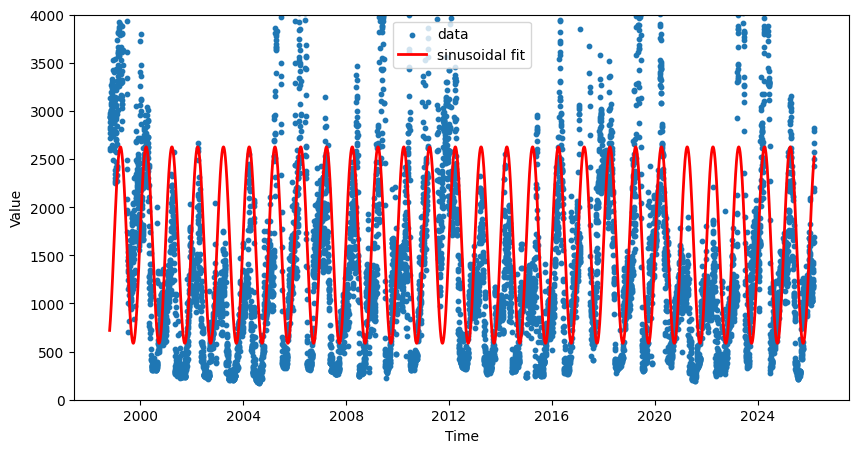

In [ ]:
#fit sinusoidal wave
x = df["days"].to_numpy()
y = df["value"].to_numpy()

def sinusoid(t, A, B, phi, C):
    return A * np.sin(B * t + phi) + C

A0 = (y.max() - y.min()) / 2
B0 = 2 * np.pi / 365.25
phi0 = 0
C0 = y.mean()

params, _ = curve_fit(sinusoid, x, y, p0=[A0, B0, phi0, C0])
A_fit, B_fit, phi_fit, C_fit = params

df["fit"] = sinusoid(df["days"], A_fit, B_fit, phi_fit, C_fit)



[ 1.02539479e+03 -1.14923917e+00  6.45879562e+02  1.27589122e+00
  1.60778548e+03]


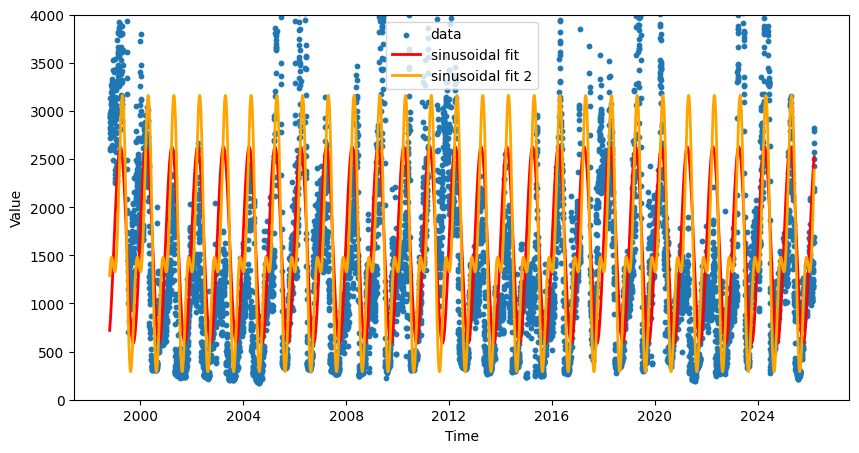

In [33]:
#fit attempt 2
def seasonal_two_harmonics(t, A1, phi1, A2, phi2, C):
    omega = 2 * np.pi / 365.25
    return (
        A1 * np.sin(omega * t + phi1)
        + A2 * np.sin(2 * omega * t + phi2)
        + C
    )

p0 = [
    (y.max() - y.min()) / 2, 0,
    (y.max() - y.min()) / 4, 0,
    y.mean()
]

params2, _ = curve_fit(seasonal_two_harmonics, x, y, p0=p0)
print(params)
df["fit2"] = seasonal_two_harmonics(df["days"], *params2)

plt.figure(figsize=(10, 5))
plt.scatter(df["time"], df["value"], s=10, label="data")
plt.plot(df["time"], df["fit"], linewidth=2, label="sinusoidal fit", c='r')
plt.plot(df["time"], df["fit2"], linewidth=2, label="sinusoidal fit 2", c='orange')
plt.xlabel("Time")
plt.ylabel("Value")
plt.ylim((0, 4000))
plt.legend()
plt.show()